# Week 4: Predictive Performance Audit Console

## Project Objective

The objective of this project is to build a rigorous evaluation engine
to measure predictive performance beyond simple accuracy, analyze
algorithmic variance and bias, and package an end-to-end execution pipeline.

### Key Tasks

- Evaluate classification models using Precision, Recall, F1-Score, and ROC-AUC.
- Generate and analyze confusion matrices.
- Compare ROC curves of different classification models.
- Perform 5-fold cross-validation to evaluate model stability.
- Audit models for overfitting using training and testing performance.
- Compare Logistic Regression and Decision Tree models.

### Models Evaluated

1. Logistic Regression
2. Decision Tree Classifier

In [1]:
# Import required libraries

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 1. Data Loading

The feature matrix and target variable generated during Week 3 are loaded
into the Week 4 evaluation pipeline.

- Feature matrix: `final_feature_matrix.csv`
- Target variable: `target_churn.csv`
- Expected feature matrix shape: 15,000 records × 61 features
- Expected target shape: 15,000 records

In [2]:
# Load Week 3 feature matrix and target variable

X = pd.read_csv("final_feature_matrix.csv")
y = pd.read_csv("target_churn.csv").squeeze()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (15000, 61)
Target shape: (15000,)

Target distribution:
churn
0    12702
1     2298
Name: count, dtype: int64


## 2. Data Verification

Before model evaluation, the dataset is checked for:

- Number of records
- Number of features
- Missing values
- Duplicate rows

This ensures that the input data is clean and suitable for evaluation.

In [3]:
# Verify input data

print("Number of records:", len(X))
print("Number of features:", X.shape[1])
print("Missing values:", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())

Number of records: 15000
Number of features: 61
Missing values: 0
Duplicate rows: 0


## 3. Train-Test Split

The dataset is divided into 80% training data and 20% testing data.

Stratified splitting is used to maintain the same class distribution
in both training and testing datasets.

A fixed random state of 42 is used to ensure reproducibility.

In [4]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (12000, 61)
Testing data shape: (3000, 61)

Training target distribution:
churn
0    10162
1     1838
Name: count, dtype: int64

Testing target distribution:
churn
0    2540
1     460
Name: count, dtype: int64


## 4. Model Training

Two supervised classification algorithms are trained using the training dataset:

1. Logistic Regression
2. Decision Tree Classifier

These models will be evaluated using multiple performance metrics rather than accuracy alone.

In [5]:
# Train Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


## 5. Decision Tree Training

A Decision Tree Classifier is trained on the same training dataset.

The Decision Tree provides a second supervised learning approach for comparison with Logistic Regression.

In [6]:
# Train Decision Tree

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


## 6. Classification Performance Evaluation

Both trained models are evaluated on the testing dataset using:

- Precision
- Recall
- F1-Score
- ROC-AUC
- Training Accuracy
- Testing Accuracy

These metrics provide a more complete view of model performance than accuracy alone.

In [7]:
# Generate predictions and probabilities

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

tree_predictions = decision_tree_model.predict(X_test)
tree_probabilities = decision_tree_model.predict_proba(X_test)[:, 1]


# Calculate Logistic Regression metrics

logistic_metrics = {
    "Precision": precision_score(y_test, logistic_predictions),
    "Recall": recall_score(y_test, logistic_predictions),
    "F1-Score": f1_score(y_test, logistic_predictions),
    "ROC-AUC": roc_auc_score(y_test, logistic_probabilities)
}


# Calculate Decision Tree metrics

tree_metrics = {
    "Precision": precision_score(y_test, tree_predictions),
    "Recall": recall_score(y_test, tree_predictions),
    "F1-Score": f1_score(y_test, tree_predictions),
    "ROC-AUC": roc_auc_score(y_test, tree_probabilities)
}


# Calculate training and testing accuracy

logistic_train_accuracy = accuracy_score(
    y_train,
    logistic_model.predict(X_train)
)

logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

tree_train_accuracy = accuracy_score(
    y_train,
    decision_tree_model.predict(X_train)
)

tree_test_accuracy = accuracy_score(
    y_test,
    tree_predictions
)


print("========== LOGISTIC REGRESSION ==========")
print(f"Training Accuracy: {logistic_train_accuracy:.4f}")
print(f"Testing Accuracy:  {logistic_test_accuracy:.4f}")

for metric, value in logistic_metrics.items():
    print(f"{metric}: {value:.4f}")


print("\n========== DECISION TREE ==========")
print(f"Training Accuracy: {tree_train_accuracy:.4f}")
print(f"Testing Accuracy:  {tree_test_accuracy:.4f}")

for metric, value in tree_metrics.items():
    print(f"{metric}: {value:.4f}")

========== LOGISTIC REGRESSION ==========
Training Accuracy: 0.8472
Testing Accuracy:  0.8447
Precision: 0.4800
Recall: 0.1565
F1-Score: 0.2361
ROC-AUC: 0.8197

========== DECISION TREE ==========
Training Accuracy: 1.0000
Testing Accuracy:  0.8560
Precision: 0.5306
Recall: 0.5283
F1-Score: 0.5294
ROC-AUC: 0.7218


## 7. Model Performance Comparison

The performance of Logistic Regression and Decision Tree is compared using
training accuracy, testing accuracy, Precision, Recall, F1-Score, and ROC-AUC.

This comparison helps identify the strengths and limitations of each model.

In [8]:
# Create model performance comparison table

metrics_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Training Accuracy": [
        logistic_train_accuracy,
        tree_train_accuracy
    ],
    "Testing Accuracy": [
        logistic_test_accuracy,
        tree_test_accuracy
    ],
    "Precision": [
        logistic_metrics["Precision"],
        tree_metrics["Precision"]
    ],
    "Recall": [
        logistic_metrics["Recall"],
        tree_metrics["Recall"]
    ],
    "F1-Score": [
        logistic_metrics["F1-Score"],
        tree_metrics["F1-Score"]
    ],
    "ROC-AUC": [
        logistic_metrics["ROC-AUC"],
        tree_metrics["ROC-AUC"]
    ]
})

print(metrics_df.to_string(index=False))

              Model  Training Accuracy  Testing Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression            0.84725          0.844667   0.480000 0.156522  0.236066 0.819724
      Decision Tree            1.00000          0.856000   0.530568 0.528261  0.529412 0.721808


## 8. Confusion Matrix Analysis

Confusion matrices are generated for both models to identify correct
and incorrect classifications.

The matrix contains:

- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

In [9]:
# Generate confusion matrices

logistic_cm = confusion_matrix(y_test, logistic_predictions)
tree_cm = confusion_matrix(y_test, tree_predictions)

print("Logistic Regression Confusion Matrix:")
print(logistic_cm)

print("\nDecision Tree Confusion Matrix:")
print(tree_cm)

Logistic Regression Confusion Matrix:
[[2462   78]
 [ 388   72]]

Decision Tree Confusion Matrix:
[[2325  215]
 [ 217  243]]


## 9. Confusion Matrix Visualization

The confusion matrices are plotted as heatmaps to provide a clear visual
representation of the classification errors made by each model.

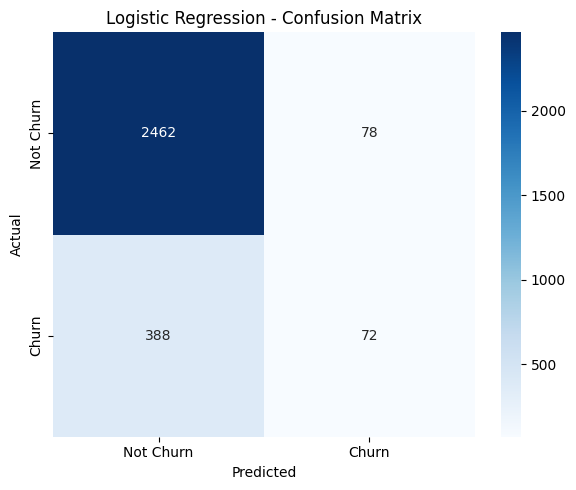

In [10]:
# Plot Logistic Regression confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 10. Decision Tree Confusion Matrix

The Decision Tree confusion matrix is visualized to identify the number
of correct and incorrect predictions for each class.

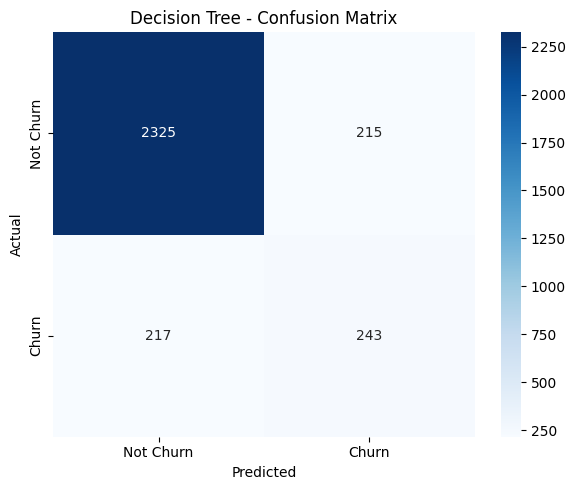

In [11]:
# Plot Decision Tree confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 11. ROC Curve Comparison

The Receiver Operating Characteristic (ROC) curve is used to compare the
ranking performance of the two classification models across different
classification thresholds.

The ROC-AUC score summarizes the overall ability of each model to
distinguish between the two classes.

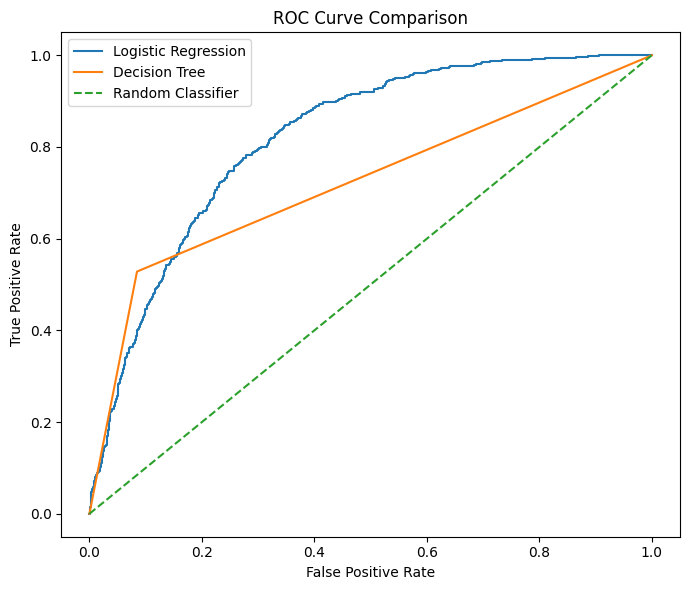

Logistic Regression ROC-AUC: 0.8197
Decision Tree ROC-AUC: 0.7218


In [12]:
# Calculate ROC curves

logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

tree_fpr, tree_tpr, _ = roc_curve(
    y_test,
    tree_probabilities
)


# Plot ROC curve comparison

plt.figure(figsize=(7, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label="Decision Tree"
)

# Random classifier reference line

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Logistic Regression ROC-AUC: {logistic_metrics['ROC-AUC']:.4f}")
print(f"Decision Tree ROC-AUC: {tree_metrics['ROC-AUC']:.4f}")

## 12. Five-Fold Cross-Validation

Five-fold stratified cross-validation is performed to evaluate model
stability across different validation folds.

F1-Score is used as the evaluation metric because the churn dataset
contains an imbalanced target distribution.

StratifiedKFold is used to maintain a similar class distribution
across all five folds.

In [13]:
# Perform 5-fold stratified cross-validation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv_scores = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)

tree_cv_scores = cross_val_score(
    decision_tree_model,
    X,
    y,
    cv=cv,
    scoring="f1"
)


# Create cross-validation results table

cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Fold 1": [
        logistic_cv_scores[0],
        tree_cv_scores[0]
    ],
    "Fold 2": [
        logistic_cv_scores[1],
        tree_cv_scores[1]
    ],
    "Fold 3": [
        logistic_cv_scores[2],
        tree_cv_scores[2]
    ],
    "Fold 4": [
        logistic_cv_scores[3],
        tree_cv_scores[3]
    ],
    "Fold 5": [
        logistic_cv_scores[4],
        tree_cv_scores[4]
    ],
    "Mean F1": [
        logistic_cv_scores.mean(),
        tree_cv_scores.mean()
    ],
    "Std F1": [
        logistic_cv_scores.std(),
        tree_cv_scores.std()
    ]
})

print(cv_results.to_string(index=False))

              Model   Fold 1   Fold 2   Fold 3   Fold 4   Fold 5  Mean F1   Std F1
Logistic Regression 0.253165 0.246711 0.267516 0.274448 0.250794 0.258527 0.010606
      Decision Tree 0.498938 0.470857 0.558980 0.542017 0.515723 0.517303 0.031128


## 13. Overfitting Audit

The training accuracy, testing accuracy, cross-validation mean F1-Score,
and cross-validation standard deviation are compared to identify
overfitting and model variance.

The train-test accuracy gap is also calculated.

A large train-test gap can indicate overfitting, while a small gap
suggests more stable generalization.

In [14]:
# Create performance audit

audit_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Training Accuracy": [
        logistic_train_accuracy,
        tree_train_accuracy
    ],
    "Testing Accuracy": [
        logistic_test_accuracy,
        tree_test_accuracy
    ],
    "CV Mean F1": [
        logistic_cv_scores.mean(),
        tree_cv_scores.mean()
    ],
    "CV Std F1": [
        logistic_cv_scores.std(),
        tree_cv_scores.std()
    ]
})

# Calculate train-test performance gap

audit_df["Train-Test Gap"] = (
    audit_df["Training Accuracy"]
    - audit_df["Testing Accuracy"]
)

print(audit_df.to_string(index=False))

              Model  Training Accuracy  Testing Accuracy  CV Mean F1  CV Std F1  Train-Test Gap
Logistic Regression            0.84725          0.844667    0.258527   0.010606        0.002583
      Decision Tree            1.00000          0.856000    0.517303   0.031128        0.144000


## 14. Performance Interpretation

### Logistic Regression

- Training accuracy: **84.73%**
- Testing accuracy: **84.47%**
- Train-test gap: **0.26 percentage points**
- Mean cross-validation F1-Score: **0.2585**
- Cross-validation standard deviation: **0.0106**
- ROC-AUC: **0.8197**

The very small train-test gap and low cross-validation variation indicate
that Logistic Regression provides stable and consistent generalization.
However, its F1-Score and recall are relatively low for the churn class.

### Decision Tree

- Training accuracy: **100%**
- Testing accuracy: **85.60%**
- Train-test gap: **14.40 percentage points**
- Mean cross-validation F1-Score: **0.5173**
- Cross-validation standard deviation: **0.0311**
- ROC-AUC: **0.7218**

The Decision Tree achieves better testing F1-Score and recall than Logistic
Regression. However, the large train-test gap indicates strong overfitting.
Its higher cross-validation variation also indicates greater model variance.

### Overall Comparison

The Decision Tree performs better on the testing F1-Score and recall,
while Logistic Regression achieves a higher ROC-AUC.

Therefore, the results show a trade-off between classification performance
at the selected threshold and overall ranking ability across thresholds.

## 15. Final Conclusion

The Predictive Performance Audit Console successfully evaluated Logistic
Regression and Decision Tree models using multiple classification metrics,
confusion matrices, ROC curves, and 5-fold cross-validation.

The audit shows that Logistic Regression is more stable and has better
ROC-AUC, while the Decision Tree provides better F1-Score and recall but
shows significant overfitting.

This evaluation demonstrates why model performance should not be judged
using accuracy alone. Precision, Recall, F1-Score, ROC-AUC, confusion
matrices, and cross-validation provide a more complete assessment of
predictive performance and model robustness.

## 16. Save Evaluation Reports

The evaluation results are saved as CSV files so that the model performance
and audit results can be reproduced and reviewed outside the notebook.

In [15]:
# Create output directories

os.makedirs("outputs/reports", exist_ok=True)


# Save model metrics

metrics_df.to_csv(
    "outputs/reports/model_metrics.csv",
    index=False
)


# Save cross-validation results

cv_results.to_csv(
    "outputs/reports/cross_validation_results.csv",
    index=False
)


# Save performance audit

audit_df.to_csv(
    "outputs/reports/performance_audit.csv",
    index=False
)


print("Evaluation reports saved successfully.")
print("\nGenerated reports:")
print("- outputs/reports/model_metrics.csv")
print("- outputs/reports/cross_validation_results.csv")
print("- outputs/reports/performance_audit.csv")

Evaluation reports saved successfully.

Generated reports:
- outputs/reports/model_metrics.csv
- outputs/reports/cross_validation_results.csv
- outputs/reports/performance_audit.csv


## 17. Save Evaluation Figures

The confusion matrices and ROC curve comparison are saved as image files
for documentation and further analysis.

In [16]:
# Create figure output directory

os.makedirs("outputs/figures", exist_ok=True)


# Save Logistic Regression confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(
    "outputs/figures/logistic_regression_confusion_matrix.png"
)

plt.close()


# Save Decision Tree confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()

plt.savefig(
    "outputs/figures/decision_tree_confusion_matrix.png"
)

plt.close()


# Save ROC curve comparison

plt.figure(figsize=(7, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    tree_fpr,
    tree_tpr,
    label="Decision Tree"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()

plt.savefig(
    "outputs/figures/roc_curve_comparison.png"
)

plt.close()


print("Evaluation figures saved successfully.")

print("\nGenerated figures:")
print("- outputs/figures/logistic_regression_confusion_matrix.png")
print("- outputs/figures/decision_tree_confusion_matrix.png")
print("- outputs/figures/roc_curve_comparison.png")

Evaluation figures saved successfully.

Generated figures:
- outputs/figures/logistic_regression_confusion_matrix.png
- outputs/figures/decision_tree_confusion_matrix.png
- outputs/figures/roc_curve_comparison.png


## 18. Week 4 Execution Summary

The Predictive Performance Audit Console was executed successfully.

### Input Dataset

- Records: **15,000**
- Features: **61**
- Missing values: **0**
- Duplicate rows: **0**
- Training records: **12,000**
- Testing records: **3,000**

### Models Evaluated

- Logistic Regression
- Decision Tree Classifier

### Evaluation Performed

- Training and Testing Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- ROC Curve
- 5-Fold Stratified Cross-Validation
- Train-Test Gap Analysis

### Generated Reports

- `model_metrics.csv`
- `cross_validation_results.csv`
- `performance_audit.csv`

### Generated Figures

- `logistic_regression_confusion_matrix.png`
- `decision_tree_confusion_matrix.png`
- `roc_curve_comparison.png`

### Final Finding

Logistic Regression demonstrated more stable generalization and higher
ROC-AUC, while the Decision Tree achieved better testing F1-Score and
Recall but showed a significant train-test performance gap, indicating
overfitting.

**Week 4 Predictive Performance Audit completed successfully.**